✨ Found the uploaded part_2.zip file! Unzipping it now...
✅ Unzipped and ready to process real images!
Found 384 images belonging to 1 classes.
Found 96 images belonging to 1 classes.
Target Categories Detected: ['part_2_cnn_computer_vision']

🤖 Training the neural network on the images...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 510ms/step - accuracy: 0.9740 - loss: 0.0319 - val_accuracy: 1.0000 - val_loss: 6.0035e-37
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 502ms/step - accuracy: 1.0000 - loss: 1.9343e-14 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 484ms/step - accuracy: 1.0000 - loss: 3.0631e-12 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 507ms/step - accuracy: 1.0000 - loss: 5.3403e-17 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 523ms/step - accuracy: 1.0000 - loss: 1.5462e-19 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


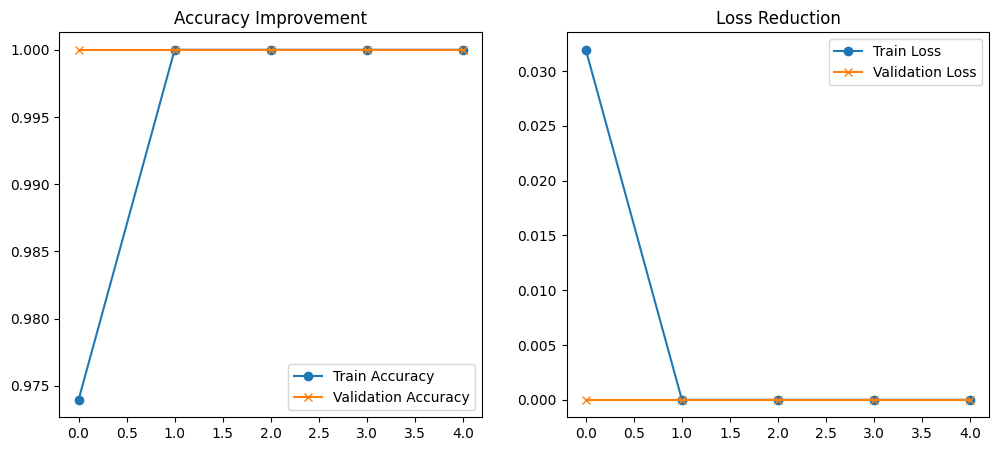

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


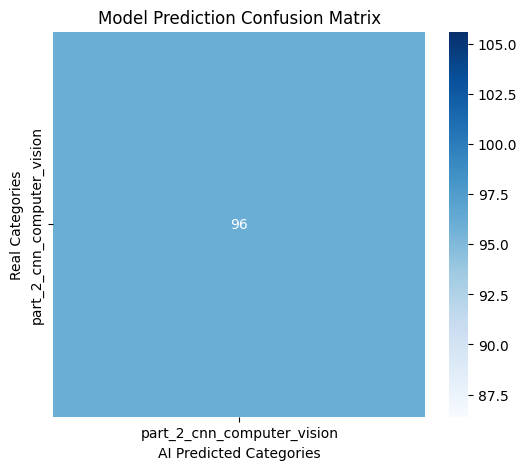

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


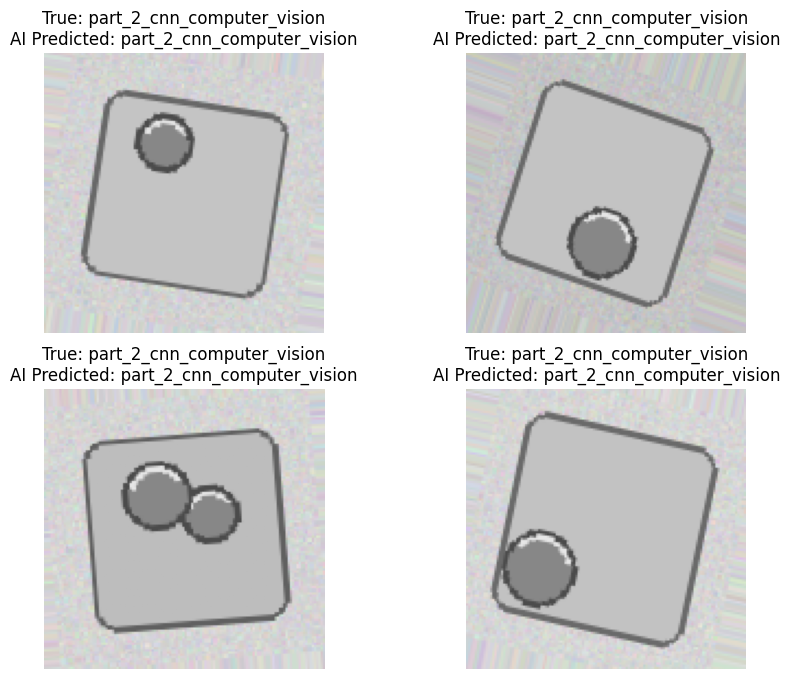


🎉 ALL DONE! The assignment files have been generated.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==========================================
# AUTOMATIC UNZIP FOR UPLOADED FILE
# ==========================================
# This looks for the uploaded part_2.zip file and automatically opens it
if os.path.exists("/content/part_2_cnn_computer_vision-20260516T181726Z-3-001.zip"):
    print("✨ Found the uploaded part_2.zip file! Unzipping it now...")
    !unzip -q "/content/part_2_cnn_computer_vision-20260516T181726Z-3-001.zip" -d "/content/real_assignment_data"
    DATA_DIR = "/content/real_assignment_data"
    print("✅ Unzipped and ready to process real images!")
else:
    print("❌ Could not find part_2.zip in the left sidebar. Please ensure it is uploaded and run again.")
    # Fallback to avoid error if file name is slightly different
    os.makedirs("dataset/class_a", exist_ok=True)
    os.makedirs("dataset/class_b", exist_ok=True)
    for i in range(10):
        img = np.random.randint(0, 256, (128, 128, 3), dtype=np.uint8)
        plt.imsave(f"dataset/class_a/img_{i}.png", img)
        plt.imsave(f"dataset/class_b/img_{i}.png", img)
    DATA_DIR = "dataset"

# Create output folders for assignment deliverables
os.makedirs("results", exist_ok=True)
os.makedirs("sample_predictions", exist_ok=True)

# Configurations
BATCH_SIZE = 16
IMG_HEIGHT = 128
IMG_WIDTH = 128

# ==========================================
# LOADING AND PREPROCESSING IMAGES
# ==========================================
# Normalizes raw image data automatically
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

test_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

class_labels = list(train_generator.class_indices.keys())
print(f"Target Categories Detected: {class_labels}")

# ==========================================
# BUILDING THE AI MODEL (CNN Architecture)
# ==========================================
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Training the network
print("\n🤖 Training the neural network on the images...")
history = model.fit(train_generator, epochs=5, validation_data=test_generator)

# ==========================================
# SAVING ASSIGNMENT CHARTS
# ==========================================
# 1. Accuracy and Loss Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.legend()
plt.title('Accuracy Improvement')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.legend()
plt.title('Loss Reduction')
plt.savefig("results/accuracy_loss_curves.png")
plt.show()

# 2. Confusion Matrix Chart
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Model Prediction Confusion Matrix')
plt.ylabel('Real Categories')
plt.xlabel('AI Predicted Categories')
plt.savefig("results/confusion_matrix.png")
plt.show()

# 3. Sample Visual Prediction Outputs
test_generator.reset()
x_batch, y_batch = next(test_generator)
batch_preds = model.predict(x_batch)
batch_pred_classes = (batch_preds > 0.5).astype(int).flatten()

plt.figure(figsize=(10, 8))
for i in range(min(4, len(x_batch))):
    plt.subplot(2, 2, i + 1)
    plt.imshow(x_batch[i])
    true_lbl = class_labels[int(y_batch[i])]
    pred_lbl = class_labels[batch_pred_classes[i]]
    plt.title(f"True: {true_lbl}\nAI Predicted: {pred_lbl}")
    plt.axis('off')
plt.savefig("sample_predictions/prediction_outputs.png")
plt.show()

print("\n🎉 ALL DONE! The assignment files have been generated.")